Import dataset and look for missing values.

In [ ]:
# import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# import dataset
df = pd.read_csv('Consumer_Shopping_Trends_2026.csv')

# prints number of missing values
print(f'Number of missing values in dataset: {df.isna().sum().sum()}')

Number of missing values in dataset: 0


**Exploratory analysis**

Plotting monthly income vs shopping preference and plotting daily internet hours vs shopping preference.

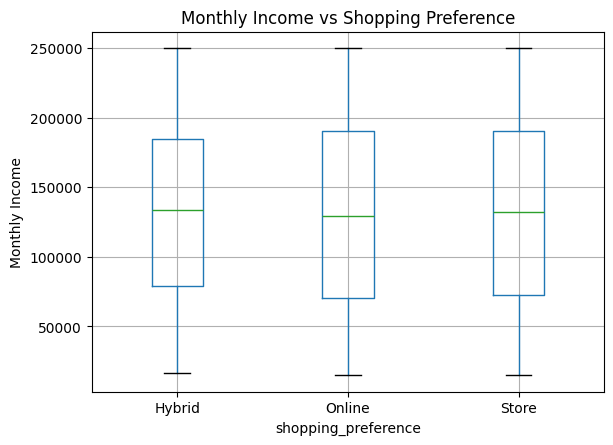

In [ ]:
df.boxplot(column='monthly_income', by='shopping_preference')
plt.title('Monthly Income vs Shopping Preference')
plt.suptitle('')
plt.ylabel('Monthly Income')
plt.show()

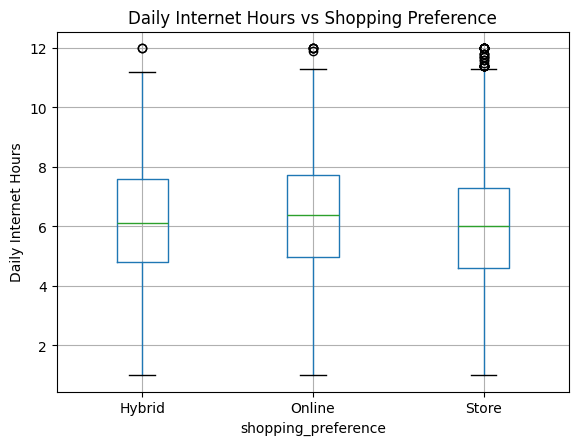

In [ ]:

df.boxplot(column='daily_internet_hours', by='shopping_preference')
plt.title('Daily Internet Hours vs Shopping Preference')
plt.suptitle('')
plt.ylabel('Daily Internet Hours')
plt.show()

**Model Implementation**

Grab features and engineer them so that they are usable by the random forest model.

In [ ]:
# import required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Remove the target column so we're left with only input features
# Convert categorical columns to numbers using one-hot encoding
# drop_first=True removes one duplicate column per category to avoid redundancy
X = df.drop(columns=['shopping_preference'])
X = pd.get_dummies(X, drop_first=True)

# Used to convert categorical labels into a numerical format
le = LabelEncoder()
y = le.fit_transform(y)

# Split data, 80% for training, 20% for testing
# random_state=42 makes the split the same every time the code runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features to have mean 0 and standard deviation 1
# We fit on training data only, then apply the same scale to test data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Create model and evaluate.

In [ ]:
# import required libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Train a random forest with 100 decision trees
# Each tree votes on a prediction, and the majority class wins
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)

# Evaluate model
print("How accurate was the model?")
print(accuracy_score(y_test, predictions))

print("\nDetailed Report:")
# Recover the original class names in the same order the encoder used
target_names = [str(cls) for cls in le.classes_]

print(classification_report(y_test, predictions, target_names=target_names))

How accurate was the model?
0.9575911789652247

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.03        72
           1       0.86      0.92      0.89       224
           2       0.97      1.00      0.98      2062

    accuracy                           0.96      2358
   macro avg       0.94      0.64      0.63      2358
weighted avg       0.96      0.96      0.94      2358



**Model Analysis**

Plot feature importance and model accuracy across three classes.

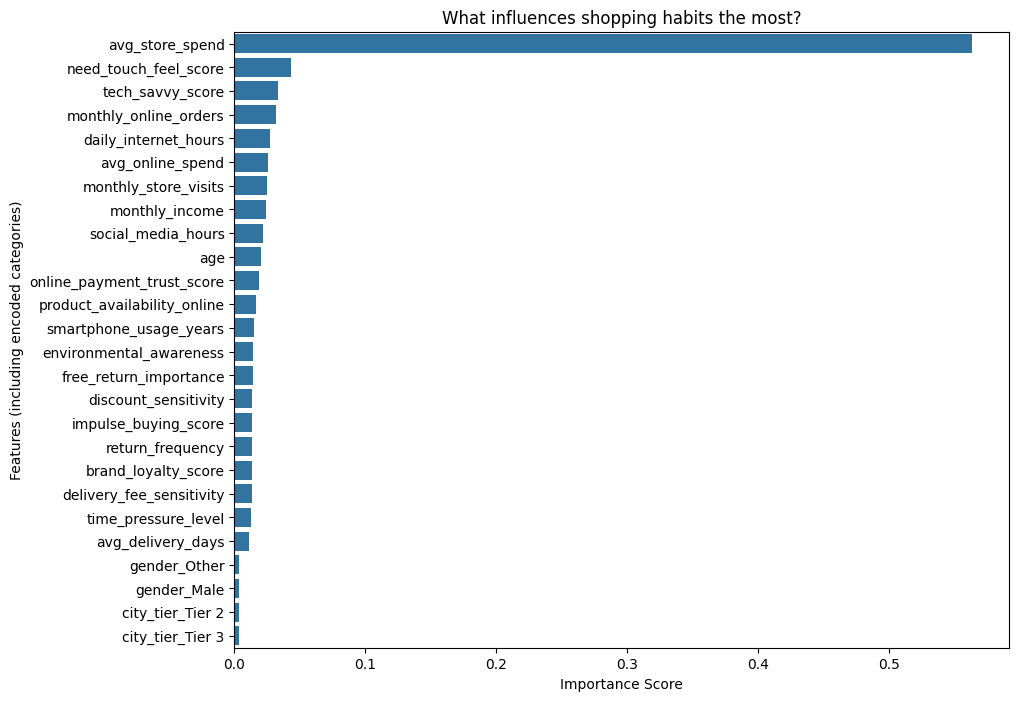

In [ ]:
# import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# feature_importances_ measures how much each feature reduced prediction error across all 100 trees
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature')

plt.title("What influences shopping habits the most?")
plt.xlabel("Importance Score")
plt.ylabel("Features (including encoded categories)")
plt.show()

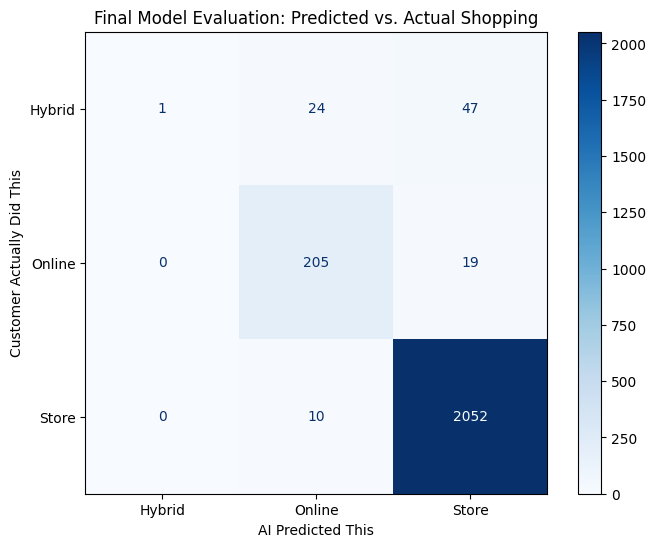

In [ ]:
# import required libraries
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Each row is the actual class, each column is what the model predicted
# Correct predictions are on the diagonal
cm = confusion_matrix(y_test, predictions)
manual_names = ['Hybrid', 'Online', 'Store']
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=manual_names)

# values_format='d' shows whole numbers instead of scientific notation
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Final Model Evaluation: Predicted vs. Actual Shopping')
plt.xlabel('AI Predicted This')
plt.ylabel('Customer Actually Did This')
plt.show()